# QAWG demo

Simple hardware flow:

1. TOF: acquire window 1.5 us, pulse 0.6 us, integration 1 us,
   trigger delay 0, then `calculate_window()` suggests the trigger delay.
2. Resonator spectroscopy near 5.9 GHz:
   `for f in freqlist: sgs.frequency = f; compiled.acquire(...)`.
3. Single shot with readout gain 0.002.
4. Heterodyne tomography for photon number and Wigner function.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt

import QAWG
from QAWG import (
    AWGAlazar,
    ExperimentProgram,
    ValuesSweep,
    calculate_window,
    ns,
    us,
)
from QAWG.instrument import RohdeSchwarzSGS100A
from QAWG.tomography import (
    heterodyne_ml_density_matrix,
    normalize_heterodyne_reference,
    project_temporal_mode,
    temporal_mode_weights,
    wigner_function,
)

print("QAWG package:", QAWG.__file__)

QAWG package: C:\Users\cluster\Desktop\Qawg-main\QAWG\__init__.py


## Hardware setup

In [2]:
AWG_RESOURCE = "TCPIP0::192.168.10.171::inst0::INSTR"
SGS100A_ADDRESS = "192.168.10.90"

AWG_SAMPLE_RATE_HZ = 2.5e9
ALAZAR_SAMPLE_RATE_HZ = 1e9

AWG_CH = 1
MARKER_CH = 1
Marker_PADDING = 500e-9
ADC_CHANNEL = "CHB"
CHANNEL_AMPLITUDE_VPP = 0.5
IF_FREQUENCY_HZ = 50e6

ACQUIRE_WINDOW = 1.5 * us
INTEGRATE_WINDOW = 1.0 * us

TOF_N_AVERAGE = 1000
SPECTROSCOPY_N_AVERAGE = 1000
SINGLE_SHOT_N_AVERAGE = 2000
TOMOGRAPHY_N_AVERAGE = 5000

In [8]:
sgs = RohdeSchwarzSGS100A(SGS100A_ADDRESS)
sgs.frequency = 5.9e9
sgs.power = 0.0
sgs.IQ_state = "on"
sgs.pulsemod_state = "off"
sgs.configure_lo_output(True, mode="LO")
sgs.on()

experiment = AWGAlazar.connect(
    AWG_RESOURCE,
    awg_sample_rate_hz=AWG_SAMPLE_RATE_HZ,
    alazar_sample_rate_hz=ALAZAR_SAMPLE_RATE_HZ,
    acquire_window_s=ACQUIRE_WINDOW,
    trigger_slope="rising",
    trigger_level=140,
    tone_frequency_hz=IF_FREQUENCY_HZ,
    integrate_window_ns=(0.0, INTEGRATE_WINDOW / ns),
    adc_channel=ADC_CHANNEL,
    moving_average_time_s=20e-9,
    baseline_time_s=100e-9,
    timeout_ms=30000,
)

print("SGS100A:", sgs.idn())
print(f"SGS frequency: {sgs.frequency / 1e9:.9f} GHz")
print("AWG/Alazar connected")

Connected to: Rohde&Schwarz,SGS100A,1416.0505k02/112369,4.2.76.0-4.30.046.295
SGS100A: Rohde&Schwarz,SGS100A,1416.0505k02/112369,4.2.76.0-4.30.046.295
SGS frequency: 5.900000000 GHz
AWG/Alazar connected


## 1. TOF

Initial post-trigger delay: 0.000 ns
Measured readout arrival: 621.184 ns
Compiled readout duration: 600.000 ns
Suggested post-trigger delay: 601.184 ns
Suggested integration window: 0.000 to 640.000 ns
DC offset removal: False
Suggested trigger delay: 601.184 ns


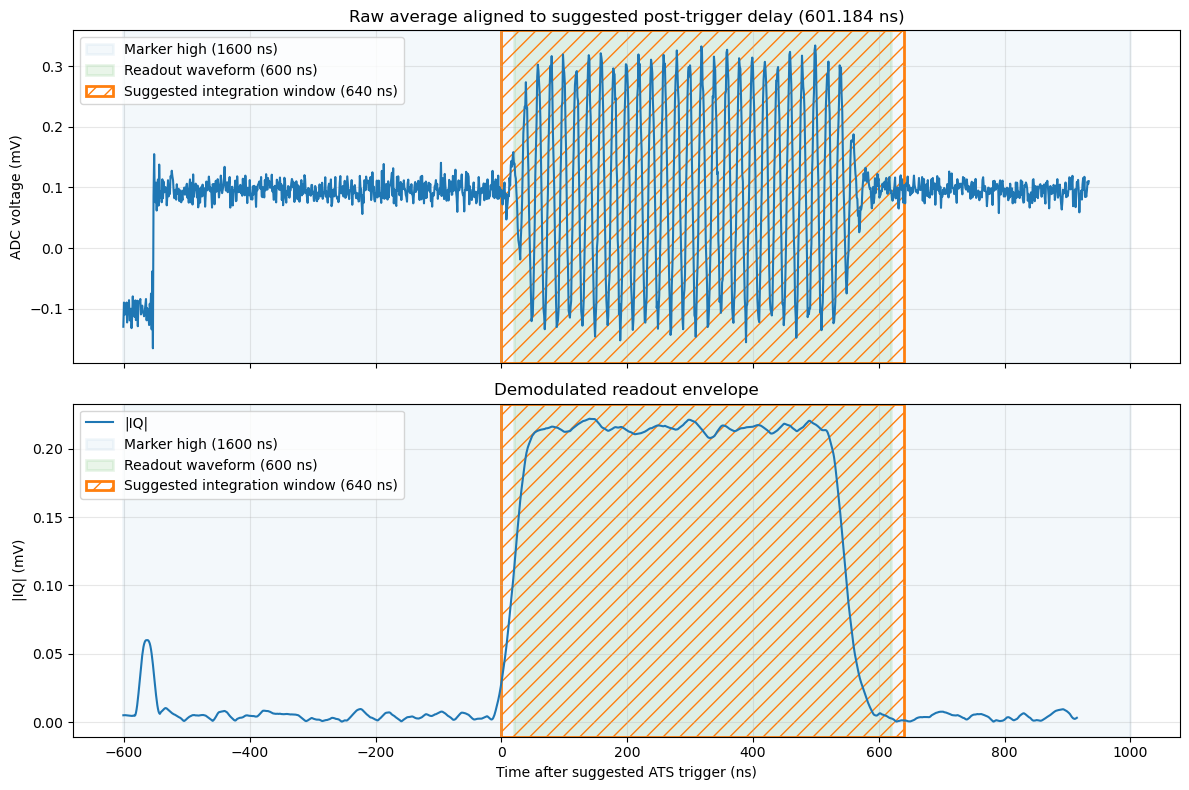

In [4]:
class TOFProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "readout",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["integrate_window"],
            demod_freq=cfg["if_frequency_hz"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_window"],
        )
        self.add_pulse(
            "tof_pulse",
            gen="readout",
            style="gaussian_square",
            length=cfg["pulse_length"],
            edge_sigma=cfg["edge_sigma"],
            frequency=cfg["if_frequency_hz"],
            gain=cfg["readout_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play("tof_pulse", at=0)
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


tof_cfg = {
    "awg_ch": AWG_CH,
    "marker_ch": MARKER_CH,
    "adc_channel": ADC_CHANNEL,
    "channel_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "if_frequency_hz": IF_FREQUENCY_HZ,
    "pulse_length": 0.6 * us,
    "integrate_window": 1.0 * us,
    "trigger_delay": 0.0,
    "edge_sigma": 20 * ns,
    "readout_gain": 1,
    "marker_padding": Marker_PADDING,
}

tof_compiled = TOFProgram(tof_cfg, final_delay_s=1 * us).compile(
    hardware=experiment,
)
tof_result = tof_compiled.acquire(
    n_average=TOF_N_AVERAGE,
    filter_type="boxcar",
)

# The physical pulse is 0.6 us, but the target integration window is 1 us.
tof_result.readout_windows_s[:] = np.array([[0.0, tof_cfg['pulse_length']]])
window = calculate_window(tof_result)

SUGGESTED_TRIGGER_DELAY = window.suggested_trigger_delay_s
print(f"Suggested trigger delay: {SUGGESTED_TRIGGER_DELAY / ns:.3f} ns")

## 2. Resonator spectroscopy

In [5]:
class ResonatorReadoutProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.declare_gen(
            "readout",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["pulse_length"],
            demod_freq=cfg["if_frequency_hz"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_window"],
        )
        self.add_pulse(
            "readout_pulse",
            gen="readout",
            style="const",
            length=cfg["pulse_length"],
            frequency=cfg["if_frequency_hz"],
            gain=cfg["readout_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play("readout_pulse", at=0)
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


readout_cfg = {
    "awg_ch": AWG_CH,
    "marker_ch": MARKER_CH,
    "adc_channel": ADC_CHANNEL,
    "channel_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "if_frequency_hz": IF_FREQUENCY_HZ,
    "pulse_length": 1.0 * us,
    "integrate_window": 1.0 * us,
    "trigger_delay": SUGGESTED_TRIGGER_DELAY,
    "readout_gain": 1,
    "marker_padding": Marker_PADDING,
}

readout_compiled = ResonatorReadoutProgram(
    readout_cfg,
    final_delay_s=1 * us,
).compile(hardware=experiment)
readout_compiled.upload()

'ResonatorReadoutProgram'

In [6]:
resonator_design = 5e9
freqlist = resonator_design -IF_FREQUENCY_HZ + np.linspace(-10e6, 10e6, 21)
resonator_iq = np.empty(freqlist.size, dtype=np.complex128)

for index, f in enumerate(freqlist):
    sgs.frequency = float(f)
    result = readout_compiled.acquire(
        n_average=SPECTROSCOPY_N_AVERAGE,
        filter_type="boxcar",
    )
    resonator_iq[index] = result.iq_average()[0]
    print(
        f"{index + 1:03d}/{freqlist.size}: "
        f"{f / 1e9:.9f} GHz, "
        f"|IQ|={abs(resonator_iq[index]) * 1e3:.4f} mV"
    )

freq_ghz = freqlist / 1e9
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(freq_ghz, np.abs(resonator_iq) * 1e3, "o-")
axes[0].set_xlabel("SGS frequency (GHz)")
axes[0].set_ylabel("|IQ| (mV)")
axes[0].grid(True, alpha=0.3)
axes[0].set_title("Resonator spectroscopy")

axes[1].plot(resonator_iq.real * 1e3, resonator_iq.imag * 1e3, "o-")
axes[1].set_xlabel("I (mV)")
axes[1].set_ylabel("Q (mV)")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.3)
axes[1].set_title("IQ circle")
plt.tight_layout()
plt.show()

best_index = int(np.argmax(np.abs(resonator_iq)))
RESONATOR_SGS_FREQUENCY = float(freqlist[best_index])
sgs.frequency = RESONATOR_SGS_FREQUENCY
print(f"Selected SGS frequency: {RESONATOR_SGS_FREQUENCY / 1e9:.9f} GHz")

001/21: 4.940000000 GHz, |IQ|=0.0022 mV
002/21: 4.941000000 GHz, |IQ|=0.0013 mV
003/21: 4.942000000 GHz, |IQ|=0.0008 mV
004/21: 4.943000000 GHz, |IQ|=0.0026 mV
005/21: 4.944000000 GHz, |IQ|=0.0020 mV
006/21: 4.945000000 GHz, |IQ|=0.0034 mV


KeyboardInterrupt: 

## 3. Single shot

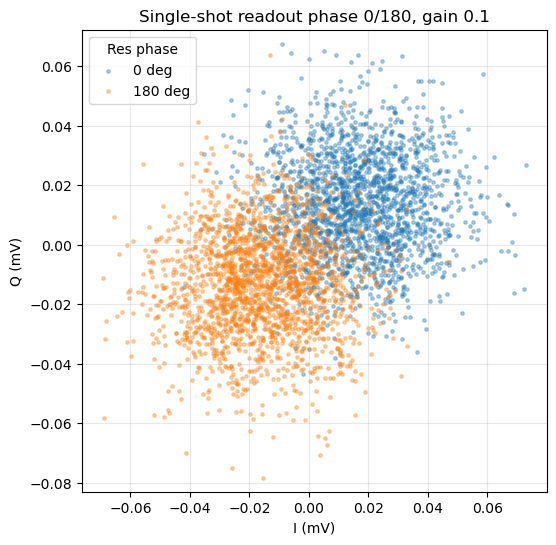

In [9]:
class DemoSingleShotProgram(ExperimentProgram):
    def _initialize(self, cfg):
        phase = self.add_sweep("res_phase", ValuesSweep((0.0, np.pi)))
        self.res_phase = phase
        self.declare_gen(
            "readout",
            ch=cfg["res_ch"],
            amplitude_vpp=cfg["res_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["ro_len"],
            demod_freq=cfg["f_res"],
            waveform_ch=cfg["res_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["integrate_time"],
        )
        self.add_pulse(
            "readout_pulse",
            gen="readout",
            style="const",
            length=cfg["res_len"],
            frequency=cfg["f_res"],
            phase=phase,
            gain=cfg["res_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play("readout_pulse", at=0)
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


single_shot_cfg = {
    "res_ch": AWG_CH,
    "marker_ch": MARKER_CH,
    "marker_padding": Marker_PADDING,
    "adc_channel": ADC_CHANNEL,
    "res_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "f_res": IF_FREQUENCY_HZ,
    "res_len": 1.0 * us,
    "ro_len": 1.0 * us,
    "res_gain": 0.1,
    "integrate_time": 1.0 * us,
    "trigger_delay": SUGGESTED_TRIGGER_DELAY,
}

single_shot_compiled = DemoSingleShotProgram(
    single_shot_cfg,
    final_delay_s=1 * us,
).compile(hardware=experiment)
single_shot_result = single_shot_compiled.acquire(
    n_average=SINGLE_SHOT_N_AVERAGE,
    filter_type="boxcar",
)

res_phases = single_shot_result.axis("res_phase")
res_phase_degrees = np.rad2deg(res_phases)
shots = single_shot_result.shots("ro")

plt.figure(figsize=(6, 6))
for step, phase_degree in enumerate(res_phase_degrees):
    plt.scatter(
        shots[:, step].real * 1e3,
        shots[:, step].imag * 1e3,
        s=6,
        alpha=0.35,
        label=f"{phase_degree:.0f} deg",
    )
plt.xlabel("I (mV)")
plt.ylabel("Q (mV)")
plt.title(f"Single-shot readout phase 0/180, gain {single_shot_cfg['res_gain']}")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend(title="Res phase")
plt.show()

## 4. Photon number and Wigner function

In [36]:
from QAWG.tomography import (
    coherent_density_matrix,

)

In [45]:
class TomographyProgram(ExperimentProgram):
    def _initialize(self, cfg):
        self.state = self.add_sweep("state", ValuesSweep(("reference", "signal")))
        self.declare_gen(
            "readout",
            ch=cfg["awg_ch"],
            amplitude_vpp=cfg["channel_amplitude_vpp"],
        )
        self.declare_readout(
            "ro",
            adc_channel=cfg["adc_channel"],
            length=cfg["readout_length"],
            demod_freq=cfg["if_frequency_hz"],
            waveform_ch=cfg["awg_ch"],
            marker_channel=cfg["marker_ch"],
            marker_padding=cfg["marker_padding"],
            integrate_time=cfg["readout_length"],
        )
        self.add_pulse(
            "reference_pulse",
            gen="readout",
            style="const",
            length=cfg["readout_length"],
            frequency=cfg["if_frequency_hz"],
            gain=0.0,
            readout=True,
        )
        self.add_pulse(
            "signal_pulse",
            gen="readout",
            style="const",
            length=cfg["readout_length"],
            frequency=cfg["if_frequency_hz"],
            gain=cfg["signal_gain"],
            readout=True,
        )

    def _body(self, cfg):
        self.play("reference_pulse", at=0, when=("state", "reference"))
        self.play("signal_pulse", at=0, when=("state", "signal"))
        self.trigger("ro", trigger_delay=cfg["trigger_delay"])


tomography_cfg = {
    "awg_ch": AWG_CH,
    "marker_ch": MARKER_CH,
    "marker_padding": Marker_PADDING,
    "adc_channel": ADC_CHANNEL,
    "channel_amplitude_vpp": CHANNEL_AMPLITUDE_VPP,
    "if_frequency_hz": IF_FREQUENCY_HZ,
    "readout_length": 0.1 * us,
    "trigger_delay": SUGGESTED_TRIGGER_DELAY,
    "signal_gain": 0.2,
}

tomography_compiled = TomographyProgram(
    tomography_cfg,
    final_delay_s=1 * us,
).compile(hardware=experiment)
tomography_result = tomography_compiled.acquire(
    n_average=TOMOGRAPHY_N_AVERAGE,
    filter_type="boxcar",
)

iq_traces = tomography_result.iq_traces
mode_samples = int(round(tomography_cfg["readout_length"] * ALAZAR_SAMPLE_RATE_HZ))
mode_samples = min(mode_samples, iq_traces.shape[2])
weights = temporal_mode_weights(mode_samples, kind="boxcar")

reference_samples = project_temporal_mode(iq_traces[:, 0, :], weights)
signal_samples = project_temporal_mode(iq_traces[:, 1, :], weights)
reference_alpha, (signal_alpha,), iq_offset, iq_scale = normalize_heterodyne_reference(
    reference_samples,
    signal_samples,
)

rho = heterodyne_ml_density_matrix(signal_alpha, cutoff=8, iterations=200)
number = np.arange(rho.shape[0], dtype=float)
photon_number = float(np.real(np.sum(number * np.diag(rho))))
purity = float(np.real(np.trace(rho @ rho)))

print(f"Photon number <n>: {photon_number:.4f}")
print(f"Purity Tr(rho^2): {purity:.4f}")

Photon number <n>: 0.4794
Purity Tr(rho^2): 0.9928


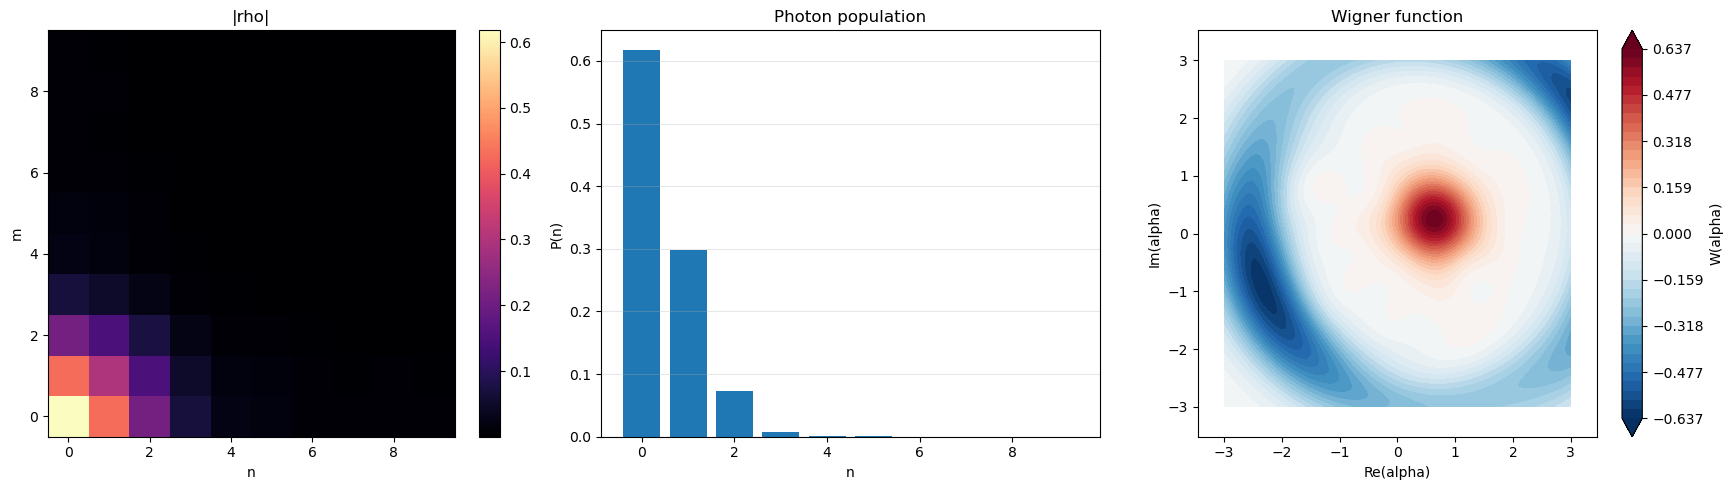

Trace rho: (1+0j)
Min eigenvalue: -2.5901117786614455e-17
Wigner minimum: -0.6300504554077212
Fidelity to coherent state at mean alpha: 0.995539458949508


In [46]:
FOCK_CUTOFF = 10
ML_ITERATIONS = 200
WIGNER_LIMIT = 3.0
WIGNER_POINTS = 81

rho_ml = heterodyne_ml_density_matrix(
    signal_alpha,
    cutoff=FOCK_CUTOFF,
    iterations=ML_ITERATIONS,
    dilution=0.5,
)

alpha_mean = np.mean(signal_alpha)
rho_coherent = coherent_density_matrix(alpha_mean, cutoff=FOCK_CUTOFF)
fidelity_to_coherent = np.real(np.trace(rho_ml @ rho_coherent))
photon_population = np.real(np.diag(rho_ml))
photon_population = np.maximum(photon_population, 0.0)

axis = np.linspace(-WIGNER_LIMIT, WIGNER_LIMIT, WIGNER_POINTS)
wigner = wigner_function(rho_ml, axis, axis)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
image = axes[0].imshow(np.abs(rho_ml), origin="lower", cmap="magma")
axes[0].set_title("|rho|")
axes[0].set_xlabel("n")
axes[0].set_ylabel("m")
plt.colorbar(image, ax=axes[0], fraction=0.046)

axes[1].bar(np.arange(FOCK_CUTOFF), photon_population)
axes[1].set_title("Photon population")
axes[1].set_xlabel("n")
axes[1].set_ylabel("P(n)")
axes[1].grid(True, axis="y", alpha=0.3)

levels = np.linspace(-2 / np.pi, 2 / np.pi, 41)
contour = axes[2].contourf(
    axis,
    axis,
    wigner,
    levels=levels,
    cmap="RdBu_r",
    extend="both",
)
axes[2].set_title("Wigner function")
axes[2].set_xlabel("Re(alpha)")
axes[2].set_ylabel("Im(alpha)")
axes[2].axis("equal")
plt.colorbar(contour, ax=axes[2], label="W(alpha)")

plt.tight_layout()
plt.show()

print("Trace rho:", np.trace(rho_ml))
print("Min eigenvalue:", np.min(np.linalg.eigvalsh(rho_ml)))
print("Wigner minimum:", np.min(wigner))
print("Fidelity to coherent state at mean alpha:", fidelity_to_coherent)


## Close hardware

In [ ]:
if "sgs" in globals():
    sgs.off()
    sgs.configure_lo_output(False)
    sgs.close()

if "experiment" in globals():
    experiment.close()